<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/SamuBenjU3proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is the True Average of Cristiano Ronaldo goals per season?

In [7]:
!pip install "preliz[full,notebook]"

In [8]:
import preliz as pz

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
import pymc as pm

##**Introduction**
In this project, I will be finding the true average Cristiano Ronaldo's goals per season. I will be using data from his 06-07 season all the way to his 23-24 season. I chose to start from his 06 season because that is when he started to score more goals. I will exclude the covid season because there was no soccer going on then.

Below here is the data for the amount of goals he scored starting from the 06-07 season to the 23-24 season. There are 18 points of data, and I will use this data to determine my prior.

In [10]:
cr7g = [
    17,
    31,
    18,
    26,
    40,
    46,
    34,
    21,
    48,
    35,
    25,
    26,
    21,
    31,
    29,
    18,
    15,
    35
]

(array([4., 2., 0., 3., 3., 1., 2., 1., 0., 2.]),
 array([15. , 18.3, 21.6, 24.9, 28.2, 31.5, 34.8, 38.1, 41.4, 44.7, 48. ]),
 <BarContainer object of 10 artists>)

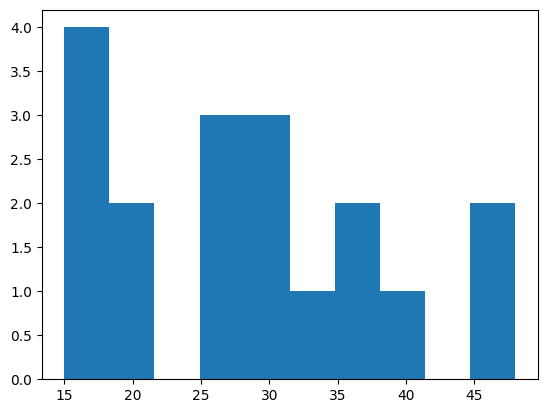

In [11]:
plt.hist(cr7g)

##**Prior**

I started with uniform distribution and half normal distribution priors. I used the uniform distribution for the mean. The half normal distribution was used for the prior standard deviations. This model also results from huge variance. I dont think think this model is going to be accurate because there will be some outliers with the use of these models.

In [12]:
with pm.Model() as model_cr7g1:
    # uniforn distribution model for the mean
    μ = pm.Uniform('μ', lower=15, upper=50)

    #half normal distribution for standard deviation
    σ = pm.HalfNormal('σ', sigma=5)

    #likelihood
    Y = pm.Normal('Y', mu = μ, sigma = σ, observed=cr7g)
    idata = pm.sample()

Output()

Output()

Output()

<Axes: xlabel='Y'>

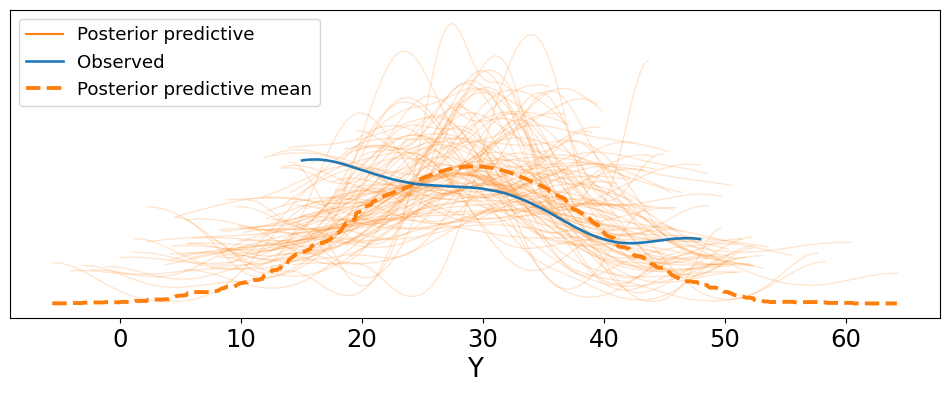

In [13]:
pm.sample_posterior_predictive(idata, model=model_cr7g1, extend_inferencedata=True)
az.plot_ppc(idata, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

This model did not fit the likelihood because the data is skewed to the right, but also a little bimodel. I will use a normal distribution and then use a skew student t distribution. I will use this distribution because to better align witht the observation.

In [21]:
#ST is for skew T
with pm.Model() as model_cr7g2:
    #normal distribution for the mean
    μ = pm.Normal('μ', mu=27, sigma=10)

    #half normal distribution for standard deviation
    σ = pm.HalfNormal('σ', sigma=5)

    # Priors for the skew parameters
    a = pm.HalfNormal('a', sigma=2)
    b = pm.HalfNormal('b', sigma=10)

    #SkewStudentT liklihood
    y = pm.SkewStudentT('y',mu=μ, sigma=σ, a = a, b = b, observed=cr7g)
    idataST = pm.sample()

Output()

Output()

ERROR:pymc.stats.convergence:There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

(10.0, 50.0)

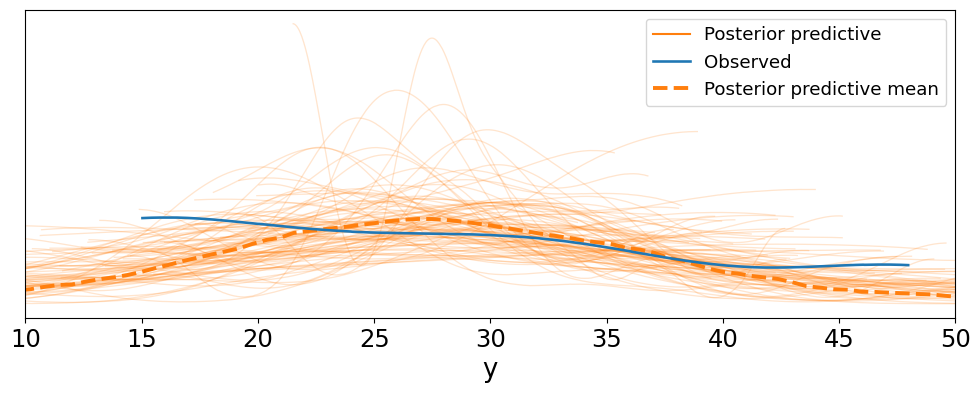

In [22]:
pm.sample_posterior_predictive(idataST, model=model_cr7g2, extend_inferencedata=True)
ax = az.plot_ppc(idataST, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])
ax.set_xlim(10,50) #limiting the frame so it's easier to see

I have now the right model because this fits the likelihood. I can tweek this to make it match more by adusting the mean to reflect the data to have a more accurate model.

In [23]:
#ST is for skew T
with pm.Model() as model_cr7g3:
    #normal distribution for the mean. Adjusted mean to better reflect data
    μ = pm.Normal('μ', mu=30, sigma=10)

    #half normal distribution for standard deviation. Increased sigma to account for higher spread
    σ = pm.HalfNormal('σ', sigma=10)

    # Priors for the skew parameters
    a = pm.HalfNormal('a', sigma=2)
    b = pm.HalfNormal('b', sigma=10)

    #SkewStudentT liklihood
    y = pm.SkewStudentT('y',mu=μ, sigma=σ, a = a, b = b, observed=cr7g)
    idataST = pm.sample()

Output()

Output()

Output()

(10.0, 50.0)

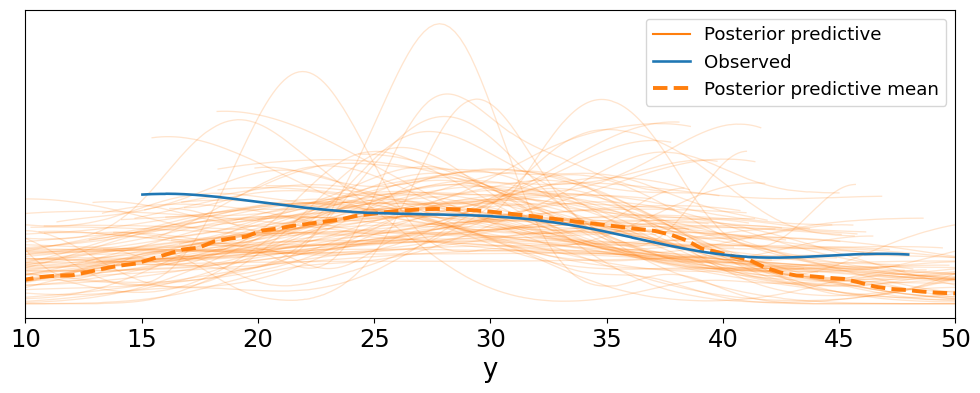

In [24]:
pm.sample_posterior_predictive(idataST, model=model_cr7g3, extend_inferencedata=True)
ax = az.plot_ppc(idataST, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])
ax.set_xlim(10,50) #limiting the frame so it's easier to see

The Skew StudentT distributuion model suits this data set the best. The tails at the ends are outliers from the data.

##**Conclusion**
My model for this data shows the average goal count per season for Cristiano Ronaldo per season. The data shows the average to be 30 goals per season. This data set also shows the outlier seasons, where Ronaldo exceeded and also underpreformed at 48 goals and 15 goals respectivly.
